# Applied Deep Learning 2026 - "Exercise 0" - Introduction to Colab and some useful python skills

The excercises in this seminar are designed to work well in the Google Colab environments. You are free to run them on your local computer or another platform of your choice of course.

As first step in *every* exercise, create a copy of every notebook for yourself with "File -> Save a copy in Drive".

When you execute the first code cell in the notebooks of the exercises, Colab will ask you, whether this is safe. You can happily click "Run anyway" because you trust your lecturers of course ;)

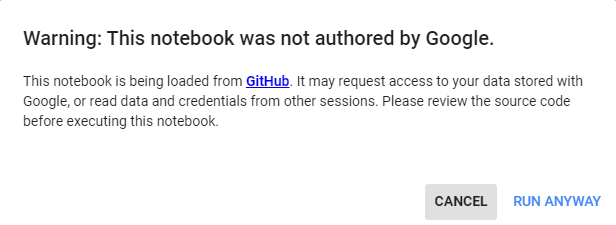

Google Colab essentiall works exactly like a Jupyter Notebook, which probably some of you are already familiar with. You can write and execute Python code interactively in every cell. The results are kept in memory until you restart the environment. Many Python packages like `numpy` or `scipy` are already preinstalled:

In [2]:
import numpy as np

x = np.linspace(0, 2*np.pi, 100) # create 100 linearly spaced numbers from 0 to 2*pi
y = np.sin(x) # compute the sine of those values

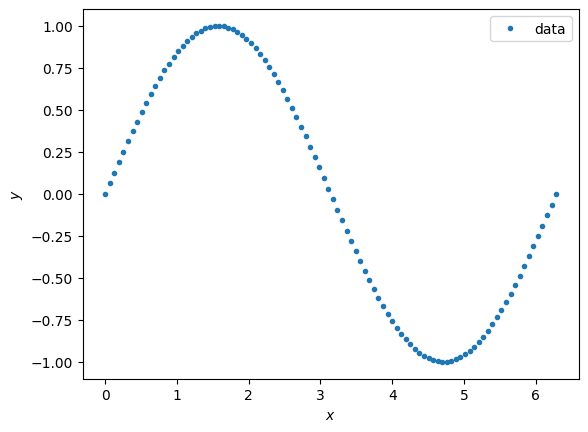

In [3]:
import matplotlib.pyplot as plt

plt.plot(x, y, '.', label='data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='best'); # remove the `;` to see what changes
# you do not need to execute plt.show() in notebooks, the plot should appear anyway.

### Excersice 0: Hints
If you put the cursor inside of the brackets of a function, what happens if you hit `Shift+Tab` and then type anything (like a space or comma)? What about `Ctrl + Space`?

### Answer

`Shift+Tab` : It shows all the information about that function, including the parameter names, their types, default values and a description of what the function does. It's basically inline documentation without leaving your notebook.

`Ctrl + Space` : This triggers autocomplete. It suggests variable names, function names, or attributes that are already defined in your notebook/function.

# Python packages used throughout the course

The most important Python packages, besides the machine learning libraries we will use ([`scikit-learn`](https://scikit-learn.org/stable/) and [`tensorflow`/`keras`](https://www.tensorflow.org/api_docs)), are certainly [`numpy`](https://numpy.org/doc/stable/contents.html), [`matplotlib`](https://matplotlib.org/stable/index.html) and [`pandas`](https://pandas.pydata.org/docs/index.html). Additionally, [`seaborn`](https://seaborn.pydata.org/) is a very use- and powerful visualization library.

# <a href=https://numpy.org><img src="https://numpy.org/images/logo.svg" width=50 align=center>numpy</a> refresher
If you do not already know, you will learn that the world of machine learning is full of vectors and matrices. In Python, `numpy` is the tool of choice to handle those.


In [4]:
vec = np.array([1,2,3,4,5,6])
print(vec)

[1 2 3 4 5 6]


In [5]:
print('Shape of vec:', vec.shape)
print('Size of vec:', vec.size)
print('Dimension of vec:', vec.ndim)

Shape of vec: (6,)
Size of vec: 6
Dimension of vec: 1


In machine learning frameworks it is common, that both the design matrix `X` (the data we want to use for trainig) and the target vector `y` (the labels or whatever we want to predict as goal of the training) are expected in the form `SxF` (S,F) where `S` are the samples and `F` are the features.

In many cases, especially the target `y` has the shape like the vector we just created `(S,)`, in our case `(6,)`. This means, as you can see from the output of `vec.ndim`, that the vector is one-dimensional. There are two commonly used ways to change this to match the expected form for machine learning libraries:

In [6]:
# reshape the existing vector into a SxF matrix
y = vec.reshape(6, 1)
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


In [7]:
# create a new dimension to transform the vector into a matrix
y = vec[:, np.newaxis]
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


### Exercise 1: Row or column vector?

A common task in the background for machine learning are vector and matrix multiplications. Inspect the following commands. Which ones work, which ones give errors? If there is an error, why does it occur? If it works, what do they compute? What is a row vector, what a column vector in numpy? And what is the difference between those two anyway?

- `a = vec.reshape(-1, 1)`
- `b = vec.reshape(1, -1)`
- `c = vec.reshape(2, 3)`
- `d = vec.reshape(-1, 3)`
- `d = vec.reshape(-1, -1)`
- `e = vec[..., np.newaxis]`
- `f = c[:, np.newaxis]`
- `g = c[np.newaxis, :, :]`
- `h = c[np.newaxis, ...]`
- `i = np.dot(vec, vec)`
- `j = vec @ vec`
- `k = vec.T`
- `l = a.T`
- `m = np.dot(a, vec)`
- `n = c @ d`
- `o = c.T @ d`
- `p = c @ d.T`
- `q = c @ d.T @ c`
-` r = np.dot(c, d.T)`
- `s = np.matmul(c, d.T)`
- `t = np.dot(c, 4)`
- `u = np.dot(4, c)`
- `v = 4*c`


In [8]:
# space for a solution
a = vec.reshape(-1, 1)  # is a column vector with shape (6,1).
                        #'-1' means numpy figure out how many rows(numpy will calculate the number of rows based on the total number of elements.)

b = vec.reshape(1, -1) # row vector with shape (1,6).
c = vec.reshape(2, 3)  # shape (2, 3), 2 rows , 3 columns
d = vec.reshape(-1, 3) # numpy sees 6 elements ÷ 3 columns = 2 rows. Thus the answer will be shape(2,3)

#d = vec.reshape(-1, -1)
'''This command give: "ValueError: can only specify one unknown dimension". (-1,-1) is asking numpy to figure out both dimensions by itself.
There are 6 elements total, but there are multiple valid answers e.g. (2,3), (3,2), (6,1) etc. Numpy has no way to choose, so it actually gives an error.
so we can only use -1 for one dimension at a time and the other must be specified.'''

e = vec[..., np.newaxis] # np.newaxis adds a new dimensions. The whole command means keep all the dimensions as it is and then add a new dimensions at the end.
                        # "..." means keep all existing dimensions as they are. Also it gives the same result as a = vec.reshape(-1, 1). shape (6,1)

f = c[:, np.newaxis] # c has a shape(2, 3). in this command, ':' means keep all rows and columns as they are, then insert a new axis in the middle.
                     # Since newaxis adds a dimension of size 1 without changing the number of elements, the shape goes from (2,3) to (2,1,3).
print(f)
f.shape


g = c[np.newaxis, :, :] # add a new dimension at the beginning. Here ae two ":". First ':' means keep all the rows, 2nd ':' means keepl all the rows.
print(g.shape)          # g gives shape (1,2,3)

h = c[np.newaxis, ...] # This is same as the above. 'g' and 'h' are indeed identical. Since "..." just means keep all existing dimensions.
print(h.shape)         #  gives the same shape (1,2,3)

i = np.dot(vec, vec)   # np.dot computes the dot product of two vectors. Here it is computing dot product of "vec" with 'vec' (itslf).
print(i)

j = vec @ vec        # vec @ vec is exactly the same as np.dot(vec, vec). The @ symbol was introduced specifically for matrix/dot product operations in python.
print(j)

k = vec.T      # '.T' is used to transpose a vector/array. Here vec is 1D array so 'vec.T' does nothing It gives the same shape(6,1).
print(f'k: {k}')        #For transposing to have any effect, the array must have more than one dimension.

l = a.T   # Since a has shape (6,1), transposing it swaps the dimensions giving shape (1,6), a row vector. This works because a is 2D.
print(f'l: {l}')
print(f"l'shape: {l.shape}")

#m = np.dot(a, vec)  #For matrix multiplication inner dimensions must match. a has shape (6,1) and vec has shape (6,). The inner dimensions 1 and 6 don't match, so this gives a 'ValueError: shapes (6,1) and (6,) not aligned: 1 (dim 1) != 6 (dim 0)'.

#n = c @ d    # will not work because the number of columns of the first matrix is not equal to the number of rows of the second matrix.
              # (2,3) @ (2,3) -> gives Error

o = c.T @ d   # (3,2) @ (2,3) -> works
print(f'O: {o}')
print(f"O'shape: {o.shape}")  # shape (3,3)


p = c @ d.T         # (2,3) @ (3,2) -> works, shape (2,2)
print(f'p: {p}')
print(f'p shape: {p.shape}')


q = c @ d.T @ c   # c @ d.T gives shape (2,2). So now it becomes (2,2) @ c and (2,2) @ (2,3) → works
print(f'q: {q}')
print(f"q's shape: {p.shape}")   #shape (2,3)

r = np.dot(c, d.T) #  r is just anothe way to write c @ d.T
print(f'r: {r}')
print(f'r shape: {r.shape}')


s = np.matmul(c, d.T) # is just another way to write c @ d.T
print(f's: {s}')

t = np.dot(c, 4)  # 4 is a scalar, it  will just multiply the whole matrix 'c' by 4.
print(f't: {t}')

u = np.dot(4, c) # All t, u and v multiply every element of c by 4 and give the same result with shape (2,3)
print(f'u: {u}')

v = 4*c          # all three are same but written in difernt style.
print(f'v: {v}')

[[[1 2 3]]

 [[4 5 6]]]
(1, 2, 3)
(1, 2, 3)
91
91
k: [1 2 3 4 5 6]
l: [[1 2 3 4 5 6]]
l'shape: (1, 6)
O: [[17 22 27]
 [22 29 36]
 [27 36 45]]
O'shape: (3, 3)
p: [[14 32]
 [32 77]]
p shape: (2, 2)
q: [[142 188 234]
 [340 449 558]]
q's shape: (2, 2)
r: [[14 32]
 [32 77]]
r shape: (2, 2)
s: [[14 32]
 [32 77]]
t: [[ 4  8 12]
 [16 20 24]]
u: [[ 4  8 12]
 [16 20 24]]
v: [[ 4  8 12]
 [16 20 24]]


## Excercise 2: Creating arrays

There are many ways to create arrays in numpy. Find out what the following do, what arguments they take and create some arrays with them:
- `np.zeros( ... )`
- `np.zeros_like( ... )`
- `np.ones( ... )`
- `np.ones_like( ... )`
- `np.eye( ... )`
- `np.linspace( ... )`
- `np.logspace( ... )`
- `np.arange( ... )`

In [9]:
# space for solutions

# np.zeros(...) creates an array of a given shape filled entirely with zeros.
#it's just a matrix where every element is 0.
np.zeros(5)        # 1D array
np.zeros((2,3))    # 2D array


# np.ones(...)  creates an array of a given shape filled entirely with ones.
# it's just a matrix where every element is 1.
np.ones((3,3))


# np.zeros_like(...) takes an existing array as argument. It then creates a new array of the same shape filled with zeros.
a = np.array([[1, 2, 3],
              [4, 5, 6]])

np.zeros_like(a)  # It basically looks at an existing array "a" and says "give me something with the same shape but filled with zeros



# np.ones_like(...) same logic as above.
# np.ones_like(...) takes an existing array as argument. It then creates a new array of the same shape filled with ones.
np.ones_like(a)


# np.eye(...) gives the identity matrix, 1s on the diagonal, 0s everywhere else.
np.eye(3)  # identity matrix of shape(3,3)


# np.linspace(...), it creates several points between two numbers , for example you can create 100 linear points between any two numbers.
# np.linspace(start, stop, num)
np.linspace(5, 9, 100)


# np.logspace(...) creates points that are spaced on a logarithmic scale.
# np.logspace(start, stop, num)   # start and stop are exponents of 10.
np.logspace(1, 3, 5)              # 5 points from 10^1 to 10^3


# np.arange(...) creates a 1D array starting from start, ending just before stop, with a jump of step.
# np.arange(start, stop, step)  # a combination of "array" and "range"
np.arange(0, 10, 2)  # Note that the stop value is excluded.

array([0, 2, 4, 6, 8])

## Exercise 3: Indexing and masking

You will in many cases not want to use all values from an array/vector/matrix. To select only some of them, you need to find a way to adress only those values.
1. Create a matrix using the command `mat = np.arange(105).reshape(3, 5, 7)`. Describe the result. How many dimensions does it have, what is its shape, what is its minimum and maximum value.
2. Run the following commands and inspect the results. What do the commands do, how do they work? If there are errors, why do they occur? It can be helpful to display the matrix `mat` as well to see what's going on:
  - `mat[2, 1, 6]`
  - `mat[:, 0, 0]`
  - `mat[:, 2, 4]`
  - `mat[:, 4, :]`
  - `mat[:, :, 7]`
  - `mat[..., 5]`
  - `mat[ mat > 25 ]`
  - `mat[ mat > 25 ].shape`
  - `mat[ (mat > 25) & (mat < 50) ]`
  - `mat[ (mat > 25) and (mat < 50) ]`
  - `mat[ (mat < 10) | (mat > 90) ]`
  - `np.where( mat > 100 )`
  - `np.where( mat < 50, 0, mat)`
  - `np.where( mat < 50, 0, 1)`
  - `mat [ mat < 50 ] = -1`
  - `mat [ np.where(mat < 50) ] = -1`



In [43]:
# space for solutions
# part 1
mat = np.arange(105).reshape(3, 5, 7) # np.arange(105) gives numbers from 0 to 104 then we reshape into (3, 5, 7)
print(f'Mat has shape {mat.shape}')
print(f'Mat has {mat.ndim} dimensions') # has 3 dimensions
print(f'Minimum Value: {mat.min()} ')   # 0 min. value
print(f'Maximun Value: {mat.max()} ')   #max. value is 104


# part 2
# For mat[2, 1, 6] we calculated the exact value 83 because all three indices were specific numbers which gives a single value.
mat[2, 1, 6]          # mat is a 3D array of shape (3,5,7) filled with values 0-104.
print(mat[2, 1, 6])   # 2: 3rd block (index 2)
                      # 1: 2nd row (index 1)
                      # 6: 7th column (index 6)
                      # This selects a single element: Result: 70 + 7 + 6 = 83




mat[:, 0, 0]        # ':' means go through all 3 blocks
print(mat[:, 0, 0]) #  0:  take the first row of each block
                    #  0: take the first column of each block

# But for mat[:, 4, :] we don't calculate specific values because : means all elements in that dimension and it gives an array
mat[:, 2, 4]           # ':' at position 0, means go through all blocks
print(mat[:, 2, 4])    # 2: 2nd row(3rd index of row) inding start at 0
                       # 4: 4th column(5th index of row)


mat[:, 4, :]         # : means all blocks
print(mat[:, 4, :])  # 4: 5th row (starting from 0 index)
                     # : means all columns



mat[:, 4, :]            # Selects the 5th row from all 3 blocks and all columns.
print(mat[:, 4, :])     # ':' at position 0 means all blocks
                        # '4' selects the 5th row from each block
                        # ':' at position 2 means all columns
                        # Result shape: (3, 7)


# mat[:, :, 7]      # This gives an IndexError!
                    # mat has shape (3,5,7) so valid column indices are 0-6.
                    # Index 7 is out of bounds for axis 2 with size 7.


mat[..., 5]           # '...' means keep all existing dimensions (all blocks, all rows)
print(mat[..., 5])    # '5' selects the 6th column (index 5) from every row
                      # Result shape: (3, 5)



mat[mat > 25]         # Boolean masking: selects all elements greater than 25.
print(mat[mat > 25])   # mat > 25 creates a True/False array.
                      # Result is a flattened 1D array of all values > 25
                      # Shape: (79,) because values 26-104 = 79 elements


mat[mat > 25].shape   # confirms the shape is (79,)
print(mat[mat > 25].shape)



mat[(mat > 25) & (mat < 50)]   # Selects values greater than 25 AND less than 50
                               # '&' means both conditions must be True
                               # Returns flattened 1D array of values 26-49
                               # Shape: (24,)

#mat[(mat > 25) and (mat < 50)]    # This gives a ValueError!
                                  # 'and' is a Python keyword that works on single boolean values, not arrays.
                                  # For element-wise comparison use '&' instead.
                                  # "ValueError: The truth value of an array with more than one element is ambiguous.""



mat[(mat < 10) | (mat > 90)]              # Selects values less than 10 OR greater than 90.
print(mat[(mat < 10) | (mat > 90)])       # '|' means OR(either condition can be True)
                                          # Selects values 0-9 and 91-104
                                          # Result: flattened 1D array, shape (24,)



# This is different from boolean masking. Instead of returning the values, np.where with one argument returns the indices where the condition is True.
np.where(mat > 100)                # Returns the INDICES where condition is True, not the values!
print(np.where(mat > 100))         # Since mat is 3D, returns 3 arrays for each dimension
                                   # 4 values are greater than 100 (101,102,103,104)
                                   # All located in block 2, row 4, columns 3-6


np.where(mat < 50, 0, mat)   # If element < 50 replace with 0, otherwise keep original value
print(np.where(mat < 50, 0, mat))  # Shape stays same (3,5,7)
                             # Result: 0s where values < 50, original values where >= 50

np.where(mat < 50, 0, 1)    # If element < 50 replace with 0, otherwise replace with 1
print(np.where(mat < 50, 0, 1)) # Shape stays same (3,5,7)
                             # Result: array of only 0s and 1s

mat[mat < 50] = -1              # Replaces all values less than 50 with -1 directly in mat
                                # Uses boolean masking to select elements
                                # Modifies the original array in place!

mat[np.where(mat < 50)] = -1         # Does exactly the same thing as above
                                     # Uses np.where to get indices first, then replaces with -1
                                     # Both approaches give identical results



Mat has shape (3, 5, 7)
Mat has 3 dimensions
Minimum Value: 0 
Maximun Value: 104 
83
[ 0 35 70]
[18 53 88]
[[ 28  29  30  31  32  33  34]
 [ 63  64  65  66  67  68  69]
 [ 98  99 100 101 102 103 104]]
[[ 28  29  30  31  32  33  34]
 [ 63  64  65  66  67  68  69]
 [ 98  99 100 101 102 103 104]]
[[  5  12  19  26  33]
 [ 40  47  54  61  68]
 [ 75  82  89  96 103]]
[ 26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104]
(79,)
[  0   1   2   3   4   5   6   7   8   9  91  92  93  94  95  96  97  98
  99 100 101 102 103 104]
(array([2, 2, 2, 2]), array([4, 4, 4, 4]), array([3, 4, 5, 6]))
[[[  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0 

## Exercise 4: Random numbers and statistics

Numpy also has many functions for random number generation and statistics.
1. Look up the following functions and experiment with them to see how they work:
  - `np.random.uniform( ... )`
  - `np.random.normal( ... )`
  - `np.random.poisson( ... )`
  - `np.random.choice( ... )`
  - `np.random.shuffle( ... )`

2. More tasks with random numbers:
  - what is wrong with this: `a = np.random.shuffle(b)`
  - look up the function `plt.hist( ... )` and show histograms of a Gaussian and a normal distribution. What can you do with the parameters `range`, `bins`, `alpha`, `density`, `histtype`, `stacked`?
  - create a matrix `A` of shape (5, 4, 3, 2, 1) of Gaussian distributed values
  - what does `A.mean()` do? What does `A.mean(axis=(1,3,2))` do?
  - Does `A.std()` compute a sample or population standard deviation? What is the difference between them?
  - create another matrix `B = np.ones(shape=(6, 8, 10))`. Execute the following: `B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))`. What is the result? What happend here? In what real situations would you use `mean` here, when `sum`?


[0.10830968 0.69985327 0.10430038 0.6683002  0.10421053]
[-0.9051294   0.2589344   0.71393018 -0.97541673  1.39085839]
[4 1 2 1 1 3 3 5 0 3]
[40 40 30 10 20]
[0 0 1 1 0 0 1 0 0 0]
[2 5 1 3 4]
None
[5 4 3 2 1]


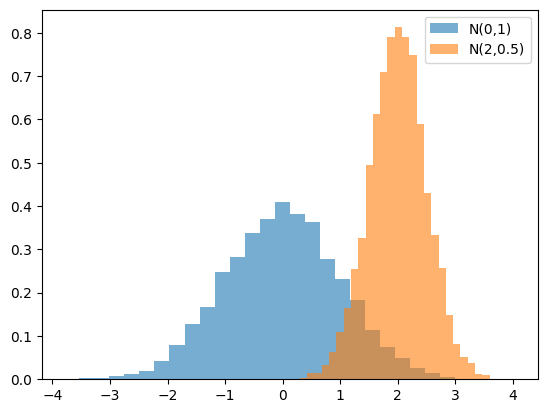

A.shape = (5, 4, 3, 2, 1)
A.mean() = -0.02510399231941202
A.mean(axis=(1,3,2)).shape = (5, 1)
A.std() = 1.0113416388860654
A.std(ddof=1) = 1.0155820836429508
B_rebin.shape = (3, 4, 5)
[[[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]]


In [83]:
# space for solutions

# np.random.uniform(a, b, size)  Generates numbers uniformly distributed between a and b. That means every value in the interval has the same probability.
x = np.random.uniform(0, 1, size=5)
print(x)


# np.random.normal(loc, scale, size) Generates numbers from a normal (Gaussian) distribution with mean loc and standard deviation scale.
x = np.random.normal(loc=0, scale=1, size=5)
print(x)

#np.random.poisson(lam, size) Generates numbers from a Poisson distribution with mean lam.
x = np.random.poisson(lam=3, size=10)
print(x)

#np.random.choice(array, size) Randomly selects elements from a given array.
x = np.random.choice([10, 20, 30, 40], size=5)
print(x)

x = np.random.choice([0, 1], size=10, p=[0.8, 0.2]) # can also choose with probabaility
print(x)


#np.random.shuffle(array) Shuffles the array in place.
b = np.array([1, 2, 3, 4, 5])
np.random.shuffle(b)
print(b)



a = np.random.shuffle(b) # a becomes None.
print(a)

np.random.shuffle(b) # correct way
a = b
print(a)

######### Histogram of a Gaussian and a normal distribution###########
#A Gaussian distribution and a normal distribution are actually the same thing.

import matplotlib.pyplot as plt

x1 = np.random.normal(loc=0, scale=1, size=10000)
x2 = np.random.normal(loc=2, scale=0.5, size=10000)

plt.hist(x1, bins=30, alpha=0.6, density=True, label='N(0,1)')
plt.hist(x2, bins=30, alpha=0.6, density=True, label='N(2,0.5)')
plt.legend()
plt.show()


#####Parameters########
# range: limits the values shown
# bins: number of bars
# alpha: transparency
# density: normalizes histogram
# histtype: style (bar, step, etc.)
# stacked: stacks multiple datasets


# Matrix A
A = np.random.normal(0, 1, size=(5, 4, 3, 2, 1))
print("A.shape =", A.shape)
print("A.mean() =", A.mean())
print("A.mean(axis=(1,3,2)).shape =", A.mean(axis=(1,3,2)).shape)
print("A.std() =", A.std())
print("A.std(ddof=1) =", A.std(ddof=1))

# Matrix B rebinning
B = np.ones(shape=(6, 8, 10))
B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))

print("B_rebin.shape =", B_rebin.shape)
print(B_rebin)

## <a href=https://pandas.pydata.org/><img src=https://pandas.pydata.org/docs/_static/pandas.svg align=center width=150></a> Pandas refresher

From the [pandas documentation](https://pandas.pydata.org/docs/getting_started/index.html):

### What kind of data does pandas handle?
When working with tabular data, such as data stored in spreadsheets or databases, pandas is the right tool for you. pandas will help you to explore, clean and process your data. In pandas, a data table is called a DataFrame.

<img src=https://pandas.pydata.org/docs/_images/01_table_dataframe.svg align=center width=300>

The pandas documentation is *that* good, that rewriting it would be pointless.

### Exercise 5: 10 minutes to pandas

To get warm with pandas, you should work your way through [this excellent quick start](https://pandas.pydata.org/docs/user_guide/10min.html#min) before you answer the following questions:
- what is a DataFrame?
- what is a Series?
- How is a Series/ DataFrame different from numpy arrays?
- How do you get numpy arrays from DataFrames?
- What do you need `.loc( ... )` for?
- What does `groupby` do? Find a real-world scenario where this might be very useful. Can you think of a potential application in machine learning?
- There are preinstalled data samples on the virtual machines running this Colab notebook. Use pandas `read_csv` to load the file `"sample_data/california_housing_train.csv"`. What do you think does this dataset describe? Look it up on the internet.
  - How many entries does the table have? How many columns? Are there missing values?
  - what are the min, max, mean and std dev of each column?
  - Create a scatterplot of `median_house_value` against `median_income`
  - Create a new column containing `total_rooms/population`.


In [84]:
!ls sample_data

anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


(17000, 9)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households      

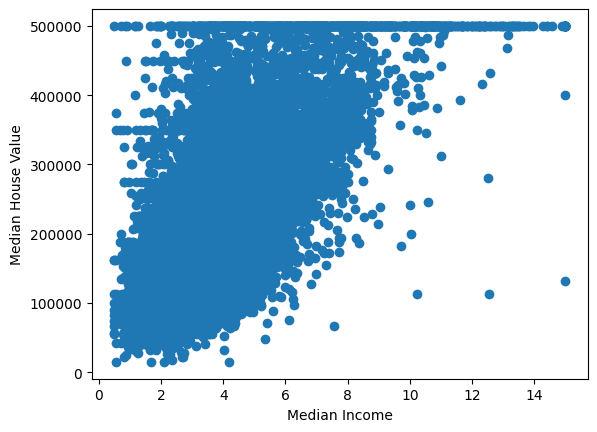

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  rooms_per_person  
0      1015.0       472.0         1.4936             66900.0          5.529064  
1      1129.0       463.0         1.8200             80100.0          6.775908  
2       333.0       117.0         1.6509             85700.0          2.162162  
3       515.0       226.0         3.1917             73400.0          2.914563  
4       624.0       262.0         1.9250             65500.0          2.330128  


In [91]:
import pandas as pd
# space for solutions


# Load data
df = pd.read_csv("sample_data/california_housing_train.csv")

# Basic info
print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())

# Scatter plot
plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

# New column
df["rooms_per_person"] = df["total_rooms"] / df["population"]
print(df.head())

# <a href=https://seaborn.pydata.org/><img src=https://seaborn.pydata.org/_static/logo-wide-lightbg.svg width=200 align=center></a> Seaborn - just a word on it

Seaborn simply makes quite nice plots. You should check out [their documentation](https://seaborn.pydata.org/). This is one example plot:

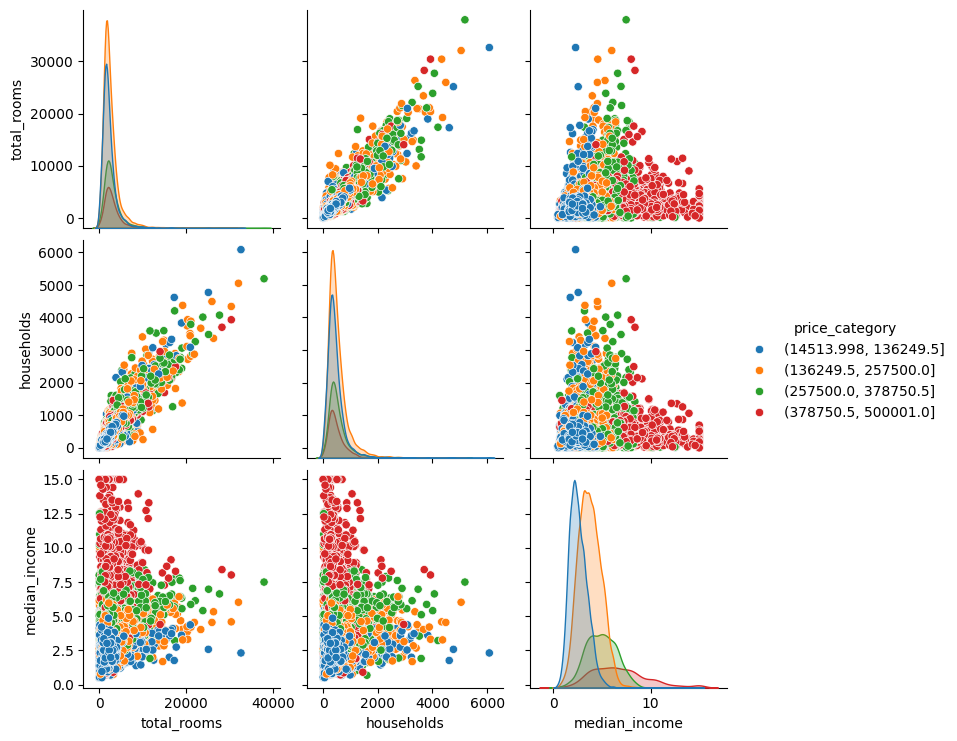

In [ ]:
import seaborn as sns
# read the csv we used before
data = pd.read_csv("sample_data/california_housing_train.csv")
# we create a new category feature dividing the house value in 4 ranges
data["price_category"] = pd.cut(data["median_house_value"], 4)
# the actual plot
sns.pairplot(data, vars=["total_rooms", "households", "median_income"], hue="price_category")

# K-Nearest Neighbors

## Excercise 6: Perform a classification using K-nearest neighbors classifier discussed in the lecture.

http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [86]:
# we load the training data from the local virtual machine as well and get a numpy array from it
mnist_train = pd.read_csv("sample_data/mnist_train_small.csv", header=None ).to_numpy()
# the first entry is the digit, the rest of the array contains the pixel values
digits_train = mnist_train[:,0]
images_train = mnist_train[:,1:]
print(digits_train.shape)
print(images_train.shape)

(20000,)
(20000, 784)


This is a 6


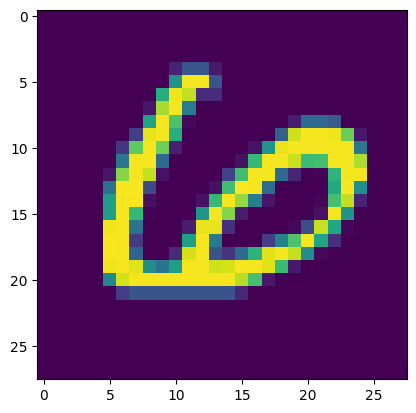

In [87]:
# the images are 28x28 but we will use the flattened array for training because KNN can only handle tabular data
plt.imshow(images_train[0].reshape(28,28));
print(f"This is a {digits_train[0]}")

In [88]:
# we train on some data and then we test on some other data, where would be the joke otherwise?
mnist_test = pd.read_csv("sample_data/mnist_test.csv", header=None ).to_numpy()
digits_test = mnist_test[:,0]
images_test = mnist_test[:,1:]

In [89]:
# import the classifier
from sklearn.neighbors import KNeighborsClassifier

# we use 7 next neighbors (this is rather much)
kn = KNeighborsClassifier(n_neighbors=7)

# for now, we will only use 100 training samples to keep the runtime low
N_samples = 100
X_train = images_train[:N_samples]
y_train = digits_train[:N_samples]
# this trains the KNN classifier. We pass the images and the digits as design matrix and target vector
kn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

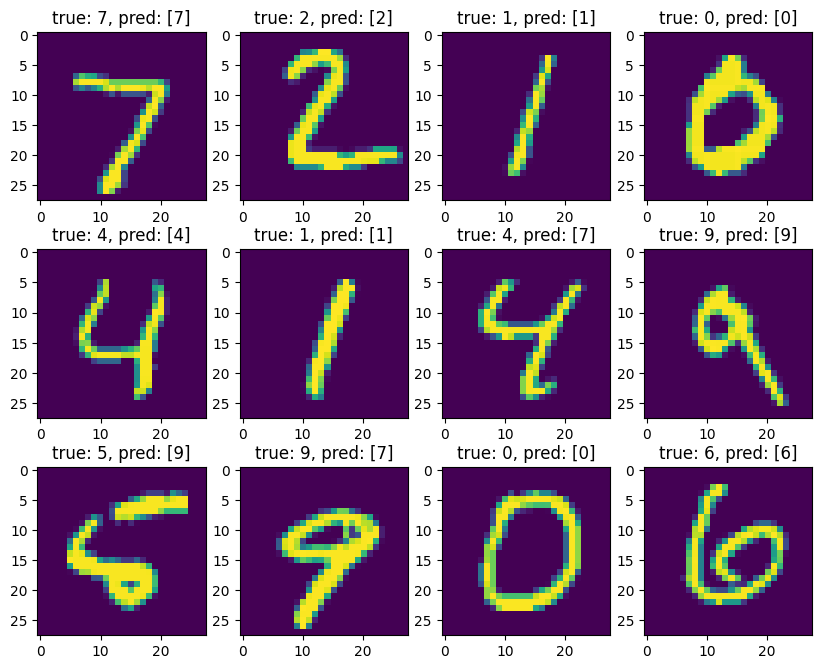

In [90]:
rows    = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10,8))

idx = 0
for r in range(rows):
  for c in range(columns):
      img        = images_test[idx].reshape(1, -1) # the shape needs to be (1, features)
      digit_true = digits_test[idx]
      digit_pred = kn.predict(img)
      axes[r, c].imshow(img.reshape(28,28))
      axes[r, c].set_title(f"true: {digit_true}, pred: {digit_pred}")
      idx += 1

# Exercise 7 - The actual tasks:
- Predict the digits for the whole training and test data set
- Compute the accuracy for both training and test predictions. How much difference is there?
- Plot some examples of misclassified digits.
- How does the performance of the algorithm change with the number of nearest neighbours?

Training accuracy: 0.61
Test accuracy: 0.5889
Difference: 0.021100000000000008


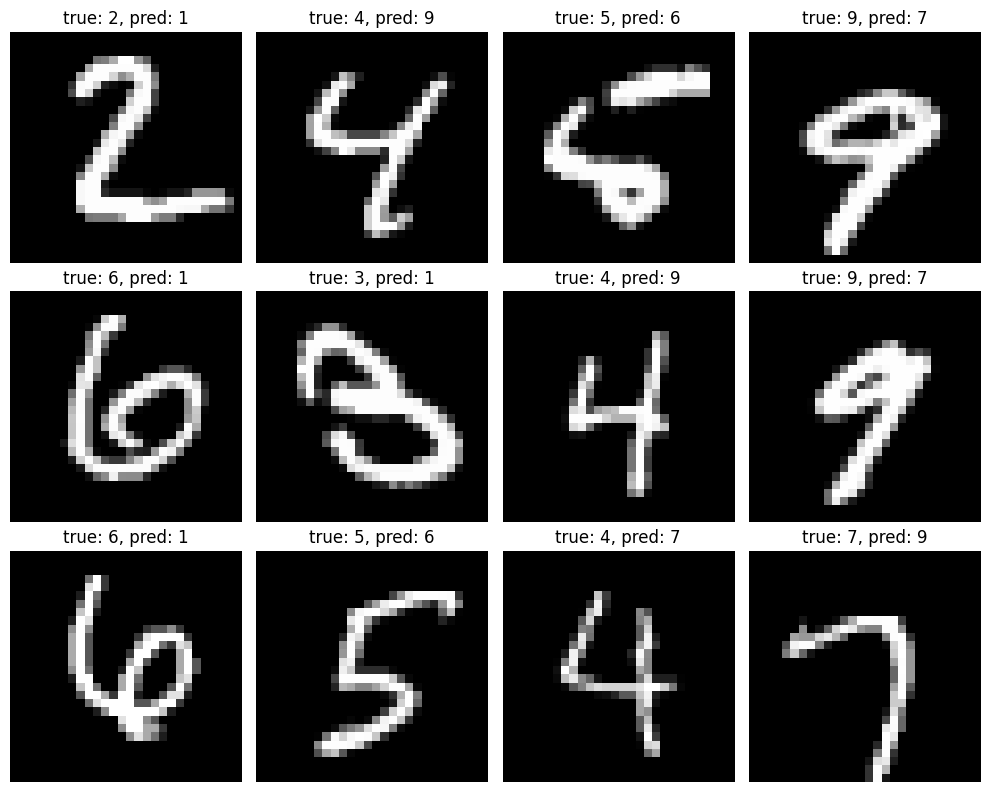

k=1: train=1.0000, test=0.7183
k=3: train=0.8800, test=0.6812
k=5: train=0.7700, test=0.6729
k=7: train=0.7600, test=0.6649
k=9: train=0.6900, test=0.6481
k=11: train=0.6700, test=0.6248
k=15: train=0.6100, test=0.5889


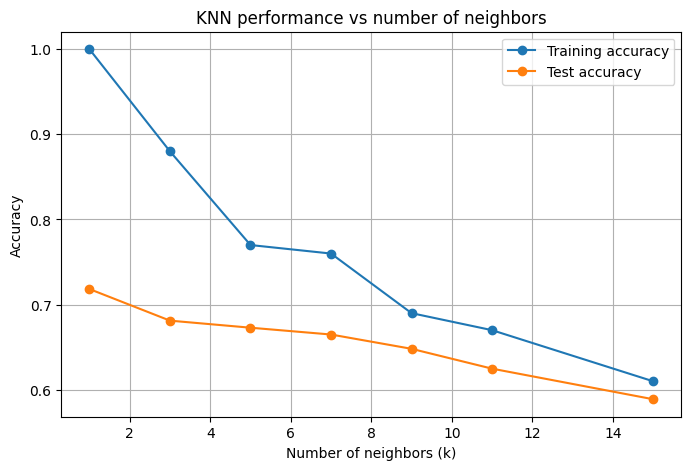

In [93]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Predict the digits for the whole training and test data set
y_train_pred = kn.predict(X_train)
y_test_pred = kn.predict(images_test)

# Compute the accuracy for both training and test predictions
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(digits_test, y_test_pred)

print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("Difference:", train_acc - test_acc)

# Plot some examples of misclassified digits
mis_idx = np.where(y_test_pred != digits_test)[0]

rows = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    idx = mis_idx[i]
    ax.imshow(images_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"true: {digits_test[idx]}, pred: {y_test_pred[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Check performance for different numbers of nearest neighbours
k_values = [1, 3, 5, 7, 9, 11, 15]
train_accuracies = []
test_accuracies = []

for k in k_values:
    kn_k = KNeighborsClassifier(n_neighbors=k)
    kn_k.fit(X_train, y_train)

    y_train_pred_k = kn_k.predict(X_train)
    y_test_pred_k = kn_k.predict(images_test)

    train_accuracies.append(accuracy_score(y_train, y_train_pred_k))
    test_accuracies.append(accuracy_score(digits_test, y_test_pred_k))

    print(f"k={k}: train={train_accuracies[-1]:.4f}, test={test_accuracies[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Training accuracy')
plt.plot(k_values, test_accuracies, marker='o', label='Test accuracy')
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN performance vs number of neighbors")
plt.legend()
plt.grid(True)
plt.show()